# 02 - Modelos Supervisados

## Contexto

El proyecto plantea tres tareas complementarias sobre el dataset de salarios de desarrolladores:

1. **Regresion:** predecir el valor numerico de `salary_usd`.
2. **Clasificacion binaria:** predecir si un perfil supera la mediana salarial del mercado (`salary_above_median`).
3. **Clustering (no supervisado):** se aborda en otro notebook a cargo del segundo integrante del equipo.

Este notebook implementa **solo regresion y clasificacion**. Para cada tarea se entrenan 4 modelos encapsulados en `Pipeline` de scikit-learn (preprocesamiento + estimador). La logica reutilizable vive en `src/model_training.py`; este notebook actua como capa de orquestacion, justificacion y comparacion.

### Modelos a entrenar

| Tarea | Modelo | Rol |
|---|---|---|
| Regresion | Linear Regression | Baseline lineal |
| Regresion | Ridge Regression | Baseline lineal con regularizacion |
| Regresion | Random Forest Regressor | Candidato a tuning (Fase 6) |
| Regresion | Gradient Boosting Regressor | Candidato a tuning (Fase 6) |
| Clasificacion | Logistic Regression | Dream Team - baseline lineal |
| Clasificacion | SVM (RBF, probability=True) | Dream Team - margen maximo |
| Clasificacion | Random Forest Classifier | Candidato a tuning (Fase 6) |
| Clasificacion | Gradient Boosting Classifier | Candidato a tuning (Fase 6) |

**Notas metodologicas:**
- Split 80/20 con `random_state=42` (reproducibilidad).
- La mediana usada como umbral de la clase binaria se calcula **solo sobre y_train** para evitar target leakage.
- No se aplica validacion cruzada ni tuning aqui (eso corresponde a las Fases 5 y 6, notebooks 03 y 04).


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Permitir importar el paquete `src` desde el notebook.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from src.model_training import (
    build_classification_pipeline,
    build_preprocessor,
    build_regression_pipeline,
    create_binary_target,
    load_data,
    save_model,
    train_and_evaluate_classification,
    train_and_evaluate_regression,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
TEST_SIZE = 0.20
MODELS_DIR = PROJECT_ROOT / 'models'
DATA_PATH = PROJECT_ROOT / 'etl' / 'data' / 'processed' / 'clean.csv'
MODELS_DIR.mkdir(parents=True, exist_ok=True)


## 1. Carga de datos

Se carga `etl/data/processed/clean.csv`, salida del pipeline ETL del Parcial 1. El dataset ya esta limpio (sin nulos, sin duplicados, con outliers tratados por capping y con las features derivadas `num_languages` y `num_frameworks`).

Se separan explicitamente las features numericas y categoricas en lugar de inferirlas, para tener control total sobre que entra al `ColumnTransformer`:

- **Numericas:** `experience`, `num_languages`, `num_frameworks`.
- **Categoricas:** `country`, `education`, `company_size`.

Las columnas crudas `languages` y `frameworks` (texto multi-valor) **se excluyen del modelado**: su informacion ya esta resumida en los conteos `num_languages` y `num_frameworks`, y procesarlas como cadenas con OneHot generaria cientos de columnas sparse con poca senal marginal.


In [2]:
df = load_data(str(DATA_PATH))
print(f'Shape: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()


Shape: 9249 filas x 10 columnas


,experience,country,education,languages,frameworks,company_size,salary_usd,num_languages,num_frameworks,salary_usd_before_cap
0,24,India,Bachelors,"Go, Ruby","Django, Flask",5000+,122189.0,2,2,122189.0
1,38,France,Masters,"Python, Ruby",Unknown,201-1000,147754.0,2,1,147754.0
2,36,USA,Some College,"C++, PHP","Ruby on Rails, Spring",5000+,220819.0,2,2,220819.0
3,3,India,Masters,"Java, JavaScript","Ruby on Rails, Spring",1-10,31943.0,2,2,31943.0
4,18,USA,Masters,"Go, Java","Django, React",5000+,166442.0,2,2,166442.0


In [3]:
NUMERIC_FEATURES = ['experience', 'num_languages', 'num_frameworks']
CATEGORICAL_FEATURES = ['country', 'education', 'company_size']
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = 'salary_usd'

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Target: {TARGET}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')


Features (6): ['experience', 'num_languages', 'num_frameworks', 'country', 'education', 'company_size']
Target: salary_usd
X shape: (9249, 6)
y shape: (9249,)


## 2. Train/test split y construccion del target binario

Se hace **un solo split** sobre el target continuo (`salary_usd`) con proporcion 80/20 y `random_state=42`. La version binaria se construye **a partir del mismo split**, usando la mediana de `y_train` como umbral.

**Por que la mediana sobre `y_train` y no sobre el dataset completo:** usar la mediana global filtra informacion del set de test al definir el umbral. Calcularla solo sobre train mantiene a test como una particion realmente "no vista". El balance de clases en train sera exactamente 50/50 por construccion; en test puede variar ligeramente.

El split estratificado **no es necesario aqui** porque el split original ya se hizo sobre el target continuo y la mediana de train da automaticamente clases balanceadas (~50/50) en train; el desbalance en test, si existe, es informacion real del particionamiento.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

y_train_bin, y_test_bin, threshold = create_binary_target(y_train, y_test)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Umbral (mediana de y_train): ${threshold:,.2f}')
print()
print('Balance de clases en TRAIN:')
print(f'  Clase 0 (<= mediana): {(y_train_bin == 0).sum()} ({(y_train_bin == 0).mean()*100:.1f}%)')
print(f'  Clase 1 (>  mediana): {(y_train_bin == 1).sum()} ({(y_train_bin == 1).mean()*100:.1f}%)')
print('Balance de clases en TEST:')
print(f'  Clase 0 (<= mediana): {(y_test_bin == 0).sum()} ({(y_test_bin == 0).mean()*100:.1f}%)')
print(f'  Clase 1 (>  mediana): {(y_test_bin == 1).sum()} ({(y_test_bin == 1).mean()*100:.1f}%)')


X_train: (7399, 6) | X_test: (1850, 6)
Umbral (mediana de y_train): $130,220.00

Balance de clases en TRAIN:
  Clase 0 (<= mediana): 3700 (50.0%)
  Clase 1 (>  mediana): 3699 (50.0%)
Balance de clases en TEST:
  Clase 0 (<= mediana): 903 (48.8%)
  Clase 1 (>  mediana): 947 (51.2%)


## 3. Construccion del preprocessor (ColumnTransformer)

Todo el preprocesamiento se hace **dentro del `Pipeline`**, no en disco. Esto garantiza que la validacion cruzada de la Fase 5 reaplique el escalado dentro de cada fold (sin leakage entre folds).

**Decisiones tecnicas:**

- **`StandardScaler` para numericas.** Justificacion: SVM (kernel RBF) y los modelos lineales con regularizacion (Ridge, Logistic con penalty L2) son sensibles a la escala de las features. Sin escalar, `experience` (0-40) dominaria a `num_languages` (0-2) en las distancias y en los terminos de regularizacion.
- **`OneHotEncoder(handle_unknown='ignore')` para categoricas.** Justificacion: `country`, `education` y `company_size` no tienen un orden numerico explotable por todos los modelos (`company_size` lo tiene parcialmente, pero One-Hot funciona correctamente para los 4 modelos elegidos sin imponer una codificacion ordinal posiblemente incorrecta). `handle_unknown='ignore'` evita que una categoria nueva en CV o en test rompa el `transform` -- en el dataset actual no deberia ocurrir, pero es la opcion robusta.


In [5]:
preprocessor = build_preprocessor(
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
)
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 4. Modelos de regresion

Se entrenan 4 modelos para predecir `salary_usd`. Para cada uno se reportan metricas en train y test (MAE, RMSE, R^2, MAPE) y el pipeline se serializa en `models/`. La comparacion entre train y test permite detectar overfitting sin necesidad todavia de validacion cruzada (eso es Fase 5).


### 4.1 Linear Regression (baseline)

**Por que:** baseline obligatorio del material del curso. Modelo lineal puro sin regularizacion, asume relacion lineal entre features y target.

**Que esperar:** el EDA mostro correlacion `experience` - `salary_usd` de 0.77, lo que sugiere componente lineal fuerte. Sin embargo, el efecto de `country` y posibles no-linealidades en `experience` (plateau a altos anos) limitaran su techo. Sirve como referencia para medir cuanto aportan modelos mas expresivos.

**Limitaciones:** sensible a outliers, no captura interacciones ni no-linealidades, puede tener problemas si hay multicolinealidad despues del one-hot.


In [6]:
reg_results = {}

pipe_lin = build_regression_pipeline(LinearRegression(), preprocessor)
reg_results['LinearRegression'] = train_and_evaluate_regression(
    pipe_lin, X_train, y_train, X_test, y_test
)
save_model(reg_results['LinearRegression']['pipeline'], str(MODELS_DIR / 'reg_linear.joblib'))

print('Linear Regression')
print(f"  Train: {reg_results['LinearRegression']['train']}")
print(f"  Test : {reg_results['LinearRegression']['test']}")


Linear Regression
  Train: {'MAE': 16000.238651432437, 'RMSE': 23572.167979990074, 'R2': 0.7634659344907567, 'MAPE': 0.128247217043578}
  Test : {'MAE': 16560.125197244924, 'RMSE': 23786.4863187392, 'R2': 0.7473085177685718, 'MAPE': 0.13059043920529304}


### 4.2 Ridge Regression

**Por que:** version regularizada (L2) de la regresion lineal. La penalizacion `alpha` reduce el efecto de coeficientes inflados por multicolinealidad introducida por el OneHotEncoder (~20-30 dummies tras el encoding).

**Que esperar:** rendimiento similar o ligeramente superior a Linear Regression en test, con coeficientes mas estables. Si Linear y Ridge son virtualmente iguales, indica que la multicolinealidad no es un problema real en este dataset.

**Limitaciones:** sigue siendo un modelo lineal -- no captura interacciones ni no-linealidades. `alpha=1.0` (default) es razonable como punto de partida; en Fase 6 se podria tunear.


In [7]:
pipe_ridge = build_regression_pipeline(Ridge(random_state=RANDOM_STATE), preprocessor)
reg_results['Ridge'] = train_and_evaluate_regression(
    pipe_ridge, X_train, y_train, X_test, y_test
)
save_model(reg_results['Ridge']['pipeline'], str(MODELS_DIR / 'reg_ridge.joblib'))

print('Ridge Regression')
print(f"  Train: {reg_results['Ridge']['train']}")
print(f"  Test : {reg_results['Ridge']['test']}")


Ridge Regression
  Train: {'MAE': 16000.764730869892, 'RMSE': 23572.18062411289, 'R2': 0.7634656807367042, 'MAPE': 0.1282739053289925}
  Test : {'MAE': 16560.728269649073, 'RMSE': 23786.12969746747, 'R2': 0.7473160947163404, 'MAPE': 0.1306177599167902}


### 4.3 Random Forest Regressor

**Por que:** ensemble basado en arboles que captura no-linealidades e interacciones automaticamente, sin requerir escalado (aunque lo aplicamos por uniformidad del pipeline). Es uno de los **dos candidatos a tuning en Fase 6**.

**Que esperar:** mejor desempeno que los lineales en test, gracias a su capacidad de modelar el plateau de `experience` y las interacciones `country x experience`. Riesgo claro de overfitting: si train ~ R^2 1.0 y test mucho menor, el modelo memorizo.

**Limitaciones:** menos interpretable que un modelo lineal, mas costoso de entrenar, propenso a overfit si los hiperparametros (`n_estimators`, `max_depth`) no se controlan. Aqui usamos defaults; el tuning va en Fase 6.


In [8]:
pipe_rfr = build_regression_pipeline(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), preprocessor
)
reg_results['RandomForestRegressor'] = train_and_evaluate_regression(
    pipe_rfr, X_train, y_train, X_test, y_test
)
save_model(
    reg_results['RandomForestRegressor']['pipeline'],
    str(MODELS_DIR / 'reg_random_forest.joblib'),
)

print('Random Forest Regressor')
print(f"  Train: {reg_results['RandomForestRegressor']['train']}")
print(f"  Test : {reg_results['RandomForestRegressor']['test']}")


Random Forest Regressor
  Train: {'MAE': 9680.614639585481, 'RMSE': 15338.60278558472, 'R2': 0.8998464739890635, 'MAPE': 0.07855536103650279}
  Test : {'MAE': 18744.2373581826, 'RMSE': 27301.863018755404, 'R2': 0.6670993969658676, 'MAPE': 0.14916950707592874}


### 4.4 Gradient Boosting Regressor

**Por que:** segundo candidato a tuning de Fase 6. A diferencia de Random Forest (arboles en paralelo, bagging), Gradient Boosting construye arboles **secuencialmente**, cada uno corrigiendo los errores del anterior. Suele superar a Random Forest en datasets tabulares medianos con relaciones complejas.

**Que esperar:** rendimiento comparable o superior a Random Forest. Con defaults (`learning_rate=0.1`, `n_estimators=100`, `max_depth=3`), suele dar buen baseline y converger de forma estable. El tuning de `learning_rate` y `n_estimators` en Fase 6 puede empujar el modelo aun mas.

**Limitaciones:** entrenamiento secuencial (no se paraleliza tan facil como Random Forest), sensible a outliers en el target, mas hiperparametros relevantes que tunear.


In [9]:
pipe_gbr = build_regression_pipeline(
    GradientBoostingRegressor(random_state=RANDOM_STATE), preprocessor
)
reg_results['GradientBoostingRegressor'] = train_and_evaluate_regression(
    pipe_gbr, X_train, y_train, X_test, y_test
)
save_model(
    reg_results['GradientBoostingRegressor']['pipeline'],
    str(MODELS_DIR / 'reg_gradient_boosting.joblib'),
)

print('Gradient Boosting Regressor')
print(f"  Train: {reg_results['GradientBoostingRegressor']['train']}")
print(f"  Test : {reg_results['GradientBoostingRegressor']['test']}")


Gradient Boosting Regressor
  Train: {'MAE': 15859.922725660444, 'RMSE': 23175.676070827063, 'R2': 0.7713561807482923, 'MAPE': 0.12835238867739898}
  Test : {'MAE': 16874.572681602895, 'RMSE': 24118.94153354243, 'R2': 0.7401955983604026, 'MAPE': 0.13447560497702363}


### 4.5 Comparacion de modelos de regresion

Tabla y bar plot sobre el conjunto de **test** -- aqui es donde se mide la capacidad de generalizacion. Los dos mejores modelos son los que pasaran a la fase de tuning (Fase 6).


In [10]:
reg_table = pd.DataFrame(
    {name: res['test'] for name, res in reg_results.items()}
).T
reg_table.index.name = 'Modelo'
reg_table_sorted = reg_table.sort_values('R2', ascending=False)
reg_table_sorted


,MAE,RMSE,R2,MAPE
Modelo,,,,
Ridge,16560.728270,23786.129697,0.747316,0.130618
LinearRegression,16560.125197,23786.486319,0.747309,0.130590
GradientBoostingRegressor,16874.572682,24118.941534,0.740196,0.134476
RandomForestRegressor,18744.237358,27301.863019,0.667099,0.149170


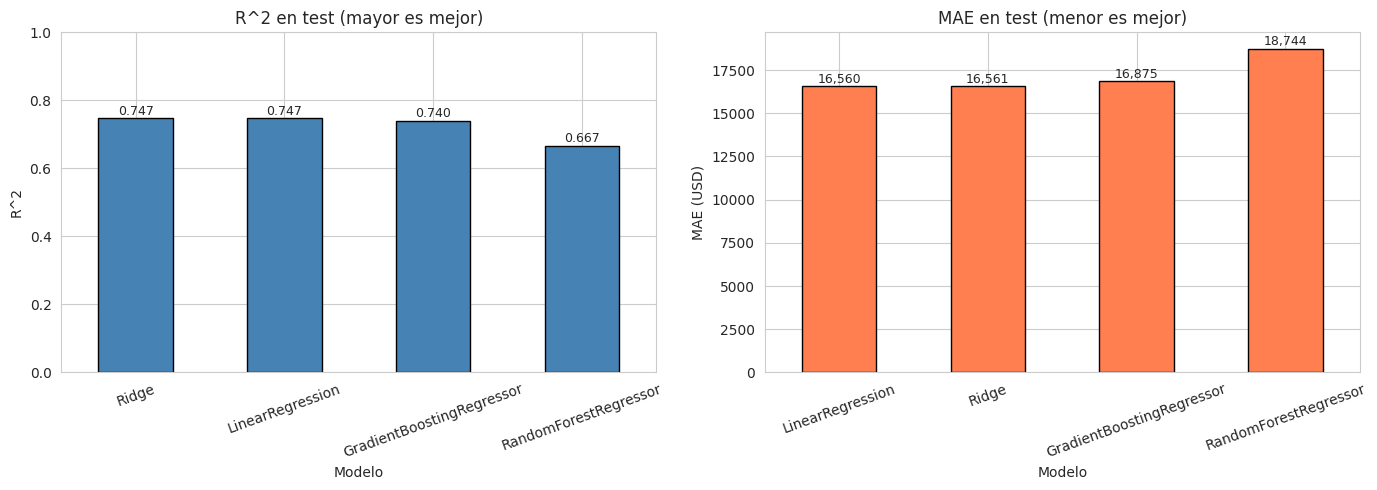

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_table_sorted['R2'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('R^2 en test (mayor es mejor)')
axes[0].set_ylabel('R^2')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(reg_table_sorted['R2']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

reg_table_sorted.sort_values('MAE')['MAE'].plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black'
)
axes[1].set_title('MAE en test (menor es mejor)')
axes[1].set_ylabel('MAE (USD)')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(reg_table_sorted.sort_values('MAE')['MAE']):
    axes[1].text(i, v + max(reg_table_sorted['MAE'])*0.01, f'{v:,.0f}',
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [12]:
print('Diagnostico train vs test (gap = train - test, indica overfitting):')
for name, res in reg_results.items():
    r2_gap = res['train']['R2'] - res['test']['R2']
    print(f'  {name:30s}  R2 train={res["train"]["R2"]:.3f}  '
          f'R2 test={res["test"]["R2"]:.3f}  gap={r2_gap:+.3f}')


Diagnostico train vs test (gap = train - test, indica overfitting):
  LinearRegression                R2 train=0.763  R2 test=0.747  gap=+0.016
  Ridge                           R2 train=0.763  R2 test=0.747  gap=+0.016
  RandomForestRegressor           R2 train=0.900  R2 test=0.667  gap=+0.233
  GradientBoostingRegressor       R2 train=0.771  R2 test=0.740  gap=+0.031


**Lectura:** los dos modelos con mejor R^2 en test, dentro del bloque de arboles (Random Forest y Gradient Boosting), son los candidatos naturales a tuning en Fase 6. Los lineales (Linear, Ridge) quedan como referencia: si despues del tuning los arboles solo empatan a los lineales, eso es senal de que el problema es esencialmente lineal y conviene preferir el modelo mas simple e interpretable.


## 5. Modelos de clasificacion

Tarea: predecir `salary_above_median` (1 si el salario supera la mediana de train, 0 en caso contrario). Se entrenan 4 modelos: dos del **"Dream Team"** (Logistic Regression y SVM -- terminologia del material del curso de Mauricio Gonzalez para el conjunto clasico de algoritmos de clasificacion lineal/margen) y dos de ensembles de arboles (Random Forest y Gradient Boosting).

Para cada modelo se reportan Accuracy, Precision, Recall, F1 y ROC-AUC en train y test, y el pipeline se serializa en `models/`.


### 5.1 Logistic Regression (Dream Team)

**Por que:** primer integrante del **Dream Team**. Es el clasificador lineal de referencia: estima `P(clase=1 | features)` con una funcion logistica sobre una combinacion lineal de las features. Interpretable, rapido, robusto.

**Que esperar:** dado que el balance de clases es ~50/50 y existen features con clara senal (`experience`, `country`), un baseline lineal deberia rondar 0.75-0.85 de accuracy facilmente. Es el suelo razonable contra el que se mide a los modelos mas complejos.

**Limitaciones:** asume frontera de decision lineal en el espacio one-hot + escalado. Si la separacion entre clases requiere combinaciones no-lineales de features, los ensembles superaran a este modelo.

Se usa `max_iter=1000` para garantizar convergencia con el dataset escalado (default `max_iter=100` puede quedarse corto con muchas dummies).


In [13]:
clf_results = {}

pipe_log = build_classification_pipeline(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000), preprocessor
)
clf_results['LogisticRegression'] = train_and_evaluate_classification(
    pipe_log, X_train, y_train_bin, X_test, y_test_bin
)
save_model(
    clf_results['LogisticRegression']['pipeline'],
    str(MODELS_DIR / 'clf_logistic.joblib'),
)

print('Logistic Regression')
print(f"  Train: {clf_results['LogisticRegression']['train']}")
print(f"  Test : {clf_results['LogisticRegression']['test']}")


Logistic Regression
  Train: {'Accuracy': 0.8783619408028112, 'Precision': 0.8820638820638821, 'Recall': 0.8734793187347932, 'F1': 0.8777506112469438, 'ROC_AUC': 0.9552510539736816}
  Test : {'Accuracy': 0.8594594594594595, 'Precision': 0.8721560130010835, 'Recall': 0.8500527983104541, 'F1': 0.8609625668449198, 'ROC_AUC': 0.94971881830014}


### 5.2 SVM (Dream Team)

**Por que:** segundo integrante del **Dream Team**. SVM con kernel RBF (default) busca el hiperplano de **margen maximo** en un espacio transformado no-lineal -- esto le da poder para capturar fronteras curvas que Logistic Regression no puede.

**Que esperar:** puede superar a Logistic Regression si la frontera real es no-lineal. En datasets de tamano medio (~9K filas) entrena en tiempo razonable. El kernel RBF es sensible al escalado, por eso `StandardScaler` dentro del pipeline es obligatorio.

**Limitaciones:** mas lento que Logistic (O(n^2) o peor), menos interpretable, requiere tuning de `C` y `gamma` para alcanzar su potencial. Se setea `probability=True` para poder calcular ROC-AUC (sklearn entrena un Platt scaling adicional, agrega costo pero es necesario para nuestra metrica de comparacion).


In [14]:
pipe_svm = build_classification_pipeline(
    SVC(probability=True, random_state=RANDOM_STATE), preprocessor
)
clf_results['SVM'] = train_and_evaluate_classification(
    pipe_svm, X_train, y_train_bin, X_test, y_test_bin
)
save_model(clf_results['SVM']['pipeline'], str(MODELS_DIR / 'clf_svm.joblib'))

print('SVM')
print(f"  Train: {clf_results['SVM']['train']}")
print(f"  Test : {clf_results['SVM']['test']}")


SVM
  Train: {'Accuracy': 0.8855250709555346, 'Precision': 0.8941404090657822, 'Recall': 0.8745606920789403, 'F1': 0.8842421757550909, 'ROC_AUC': 0.9606156886813821}
  Test : {'Accuracy': 0.8594594594594595, 'Precision': 0.8737758433079434, 'Recall': 0.8479408658922915, 'F1': 0.8606645230439443, 'ROC_AUC': 0.9459872699356012}


### 5.3 Random Forest Classifier

**Por que:** equivalente del Random Forest Regressor para clasificacion. Captura no-linealidades e interacciones automaticamente. Es uno de los **dos candidatos a tuning de Fase 6** en clasificacion.

**Que esperar:** suele dominar a los lineales en problemas con interacciones (ej. el efecto combinado de `country` + `experience`). Riesgo de overfitting visible cuando train F1 ~ 1.0 y test F1 mucho menor.

**Limitaciones:** menos interpretable (aunque expone `feature_importances_`), mayor costo computacional. Defaults para esta fase; el tuning de `n_estimators`, `max_depth`, `min_samples_leaf` va a Fase 6.


In [15]:
pipe_rfc = build_classification_pipeline(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), preprocessor
)
clf_results['RandomForestClassifier'] = train_and_evaluate_classification(
    pipe_rfc, X_train, y_train_bin, X_test, y_test_bin
)
save_model(
    clf_results['RandomForestClassifier']['pipeline'],
    str(MODELS_DIR / 'clf_random_forest.joblib'),
)

print('Random Forest Classifier')
print(f"  Train: {clf_results['RandomForestClassifier']['train']}")
print(f"  Test : {clf_results['RandomForestClassifier']['test']}")


Random Forest Classifier
  Train: {'Accuracy': 0.956750912285444, 'Precision': 0.9533136570968608, 'Recall': 0.960529872938632, 'F1': 0.956908160517102, 'ROC_AUC': 0.9943874166136939}
  Test : {'Accuracy': 0.841081081081081, 'Precision': 0.8390446521287642, 'Recall': 0.853220696937698, 'F1': 0.8460732984293193, 'ROC_AUC': 0.9235944715549832}


### 5.4 Gradient Boosting Classifier

**Por que:** segundo candidato a tuning. Como su contraparte en regresion, entrena arboles secuencialmente corrigiendo errores. Suele ser el modelo top en problemas tabulares balanceados.

**Que esperar:** rendimiento comparable o superior a Random Forest. Defaults razonables (`learning_rate=0.1`, `n_estimators=100`, `max_depth=3`); el tuning fino de Fase 6 puede dar el empujon final.

**Limitaciones:** entrenamiento secuencial (no paralelizable como RF), mas hiperparametros sensibles. La curva learning_rate vs n_estimators es un trade-off clasico a tunear.


In [16]:
pipe_gbc = build_classification_pipeline(
    GradientBoostingClassifier(random_state=RANDOM_STATE), preprocessor
)
clf_results['GradientBoostingClassifier'] = train_and_evaluate_classification(
    pipe_gbc, X_train, y_train_bin, X_test, y_test_bin
)
save_model(
    clf_results['GradientBoostingClassifier']['pipeline'],
    str(MODELS_DIR / 'clf_gradient_boosting.joblib'),
)

print('Gradient Boosting Classifier')
print(f"  Train: {clf_results['GradientBoostingClassifier']['train']}")
print(f"  Test : {clf_results['GradientBoostingClassifier']['test']}")


Gradient Boosting Classifier
  Train: {'Accuracy': 0.8826868495742668, 'Precision': 0.8810228802153433, 'Recall': 0.8848337388483374, 'F1': 0.8829241974642568, 'ROC_AUC': 0.9597203773116182}
  Test : {'Accuracy': 0.86, 'Precision': 0.8706896551724138, 'Recall': 0.853220696937698, 'F1': 0.8618666666666667, 'ROC_AUC': 0.9487254148731029}


### 5.5 Comparacion de modelos de clasificacion

Tabla y bar plot en test. Para clasificacion balanceada, `F1` y `ROC-AUC` son las metricas mas informativas: `F1` para rendimiento global en la clase positiva, `ROC-AUC` para capacidad discriminativa independiente del umbral.


In [17]:
clf_table = pd.DataFrame(
    {name: res['test'] for name, res in clf_results.items()}
).T
clf_table.index.name = 'Modelo'
clf_table_sorted = clf_table.sort_values('F1', ascending=False)
clf_table_sorted


,Accuracy,Precision,Recall,F1,ROC_AUC
Modelo,,,,,
GradientBoostingClassifier,0.860000,0.870690,0.853221,0.861867,0.948725
LogisticRegression,0.859459,0.872156,0.850053,0.860963,0.949719
SVM,0.859459,0.873776,0.847941,0.860665,0.945987
RandomForestClassifier,0.841081,0.839045,0.853221,0.846073,0.923594


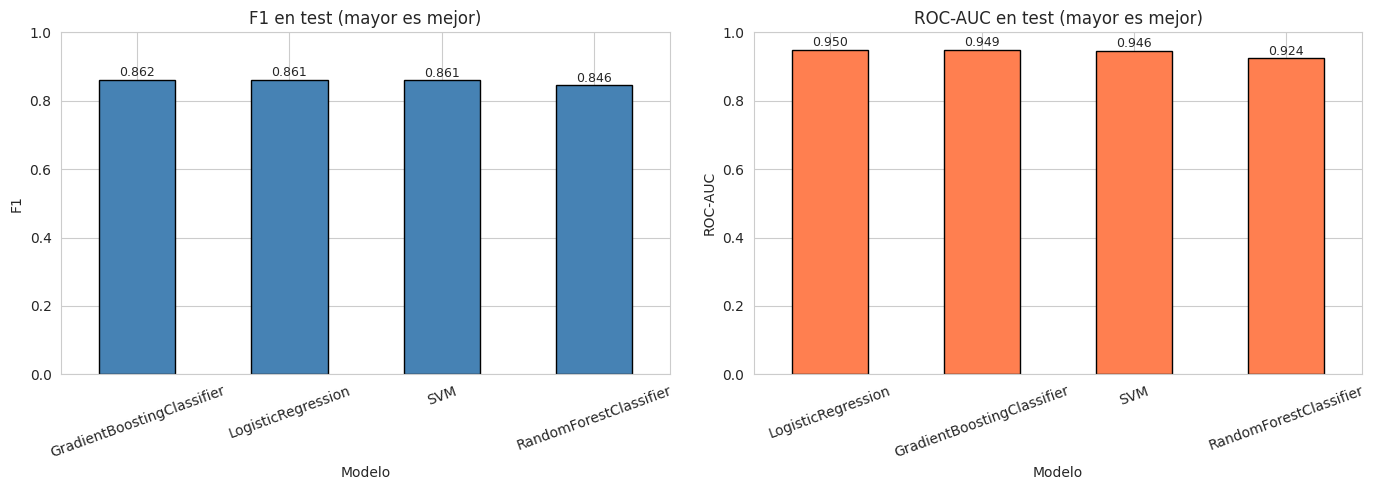

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clf_table_sorted['F1'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('F1 en test (mayor es mejor)')
axes[0].set_ylabel('F1')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(clf_table_sorted['F1']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

clf_table_sorted.sort_values('ROC_AUC', ascending=False)['ROC_AUC'].plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black'
)
axes[1].set_title('ROC-AUC en test (mayor es mejor)')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(clf_table_sorted.sort_values('ROC_AUC', ascending=False)['ROC_AUC']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [19]:
print('Diagnostico train vs test (gap = train - test, indica overfitting):')
for name, res in clf_results.items():
    f1_gap = res['train']['F1'] - res['test']['F1']
    print(f'  {name:30s}  F1 train={res["train"]["F1"]:.3f}  '
          f'F1 test={res["test"]["F1"]:.3f}  gap={f1_gap:+.3f}')


Diagnostico train vs test (gap = train - test, indica overfitting):
  LogisticRegression              F1 train=0.878  F1 test=0.861  gap=+0.017
  SVM                             F1 train=0.884  F1 test=0.861  gap=+0.024
  RandomForestClassifier          F1 train=0.957  F1 test=0.846  gap=+0.111
  GradientBoostingClassifier      F1 train=0.883  F1 test=0.862  gap=+0.021


**Lectura:** los dos modelos con mejor F1/ROC-AUC en test pasan a tuning en Fase 6. Si los del Dream Team (Logistic, SVM) quedan muy cerca de los ensembles, es senal de que la frontera de decision es casi lineal -- caso en el que Logistic Regression, por su simplicidad e interpretabilidad, puede ser el modelo preferido en produccion aunque no sea el de mayor metrica absoluta.


## 6. Cierre y siguiente paso

### Estado al cerrar la Fase 3

- 8 pipelines entrenados (4 regresion + 4 clasificacion) con preprocesamiento integrado (`StandardScaler` + `OneHotEncoder`).
- Todos los modelos serializados en `models/` como `.joblib`.
- Justificacion tecnica escrita para cada modelo.
- Metricas base (sin CV ni tuning) calculadas en train y test para detectar overfitting de entrada.
- Variable binaria construida con la mediana de **y_train** (sin leakage).

### Recomendaciones para Fase 5 (Evaluacion, notebook 03)

- Aplicar `cross_val_score` con `cv=5` o `cv=10` sobre **todos** los pipelines guardados aqui. Como el preprocesamiento esta dentro del Pipeline, sklearn lo reaplicara correctamente en cada fold.
- Calcular las mismas metricas en CV y comparar contra los valores de test de este notebook -- una metrica de test cercana a la media de CV es senal de modelo estable.
- Para clasificacion: agregar matriz de confusion y curvas ROC.
- Para regresion: agregar grafico de residuos.

### Recomendaciones para Fase 6 (Tuning, notebook 04)

- Tunear los dos mejores de cada tarea segun la tabla de comparacion (esperado: Random Forest + Gradient Boosting en ambas).
- Usar `GridSearchCV` para uno y `RandomizedSearchCV` para el otro (la rubrica IEE 2.3.1 exige ambos metodos).
- Grids sugeridos: `n_estimators`, `max_depth`, `min_samples_split` para Random Forest; `learning_rate`, `n_estimators`, `max_depth` para Gradient Boosting.

### Confirmacion

Los 8 modelos quedan disponibles en `models/`:

```
models/
  reg_linear.joblib
  reg_ridge.joblib
  reg_random_forest.joblib
  reg_gradient_boosting.joblib
  clf_logistic.joblib
  clf_svm.joblib
  clf_random_forest.joblib
  clf_gradient_boosting.joblib
```


In [20]:
print('Modelos serializados en models/:')
for p in sorted(MODELS_DIR.glob('*.joblib')):
    print(f'  {p.name}  ({p.stat().st_size / 1024:.1f} KB)')


Modelos serializados en models/:
  clf_gradient_boosting.joblib  (142.9 KB)
  clf_logistic.joblib  (4.0 KB)
  clf_random_forest.joblib  (17788.8 KB)
  clf_svm.joblib  (256.4 KB)
  reg_gradient_boosting.joblib  (142.7 KB)
  reg_linear.joblib  (3.7 KB)
  reg_random_forest.joblib  (51393.4 KB)
  reg_ridge.joblib  (3.7 KB)
